<a href="https://colab.research.google.com/github/wushuchris/aai-521-group-7/blob/TommyDev/Tommy_SLAMlite_GrapeSLAM_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Drive Setup

In [7]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Root directory in Google Drive
DATA_ROOT = '/content/drive/MyDrive/GrapeSLAM3'

# Example for one session (repeat for more, or loop over lists)
SESSION_ID = '0016'  # Change to match each video/Excel prefix

VIDEO_PATH = os.path.join(DATA_ROOT, f'DJI_{SESSION_ID}.MOV')
GT_PATH = os.path.join(DATA_ROOT, f'DJI{SESSION_ID}.xlsx')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
SESSION_IDS = ['0016', '0018', '0019']  # List all available pairs

for sid in SESSION_IDS:
    video_path = os.path.join(DATA_ROOT, f'DJI_{sid}.MOV')
    gt_path = os.path.join(DATA_ROOT, f'DJI{sid}.xlsx')

In [35]:
import pandas as pd

video_path = '/content/drive/MyDrive/GrapeSLAM3/DJI_0018.MOV'
gt_path = '/content/drive/MyDrive/GrapeSLAM3/DJI0018.xlsx'

# Load ground-truth/reference
gt_df = pd.read_excel(gt_path)

# Print columns and first few rows (will show timestamps, positions, etc.)
print("Ground-truth columns:", gt_df.columns)
print("First 5 rows of ground-truth:\n", gt_df.head())


Ground-truth columns: Index(['time(millisecond)', 'isVideo', 'datetime(utc)', 'latitude',
       'longitude', 'height_above_takeoff(feet)',
       'height_above_ground_at_drone_location(feet)',
       'ground_elevation_at_drone_location(feet)',
       'altitude_above_seaLevel(feet)', 'height_sonar(feet)', 'speed(mph)',
       'distance(feet)', 'mileage(feet)', 'satellites', 'gpslevel',
       'voltage(v)', 'max_altitude(feet)', 'max_ascent(feet)',
       'max_speed(mph)', 'max_distance(feet)', ' xSpeed(mph)', ' ySpeed(mph)',
       ' zSpeed(mph)', ' compass_heading(degrees)', ' pitch(degrees)',
       ' roll(degrees)', 'isPhoto', 'isVideo.1', 'rc_elevator', 'rc_aileron',
       'rc_throttle', 'rc_rudder', 'rc_elevator(percent)',
       'rc_aileron(percent)', 'rc_throttle(percent)', 'rc_rudder(percent)',
       'gimbal_heading(degrees)', 'gimbal_pitch(degrees)',
       'gimbal_roll(degrees)', 'battery_percent', 'voltageCell1',
       'voltageCell2', 'voltageCell3', 'voltageCell4', 'volt

## Load Data

In [36]:
import cv2
import glob
import numpy as np
from tqdm import tqdm #For progress bar

# Set the single video and matched ground-truth file
DATA_ROOT = '/content/drive/MyDrive/GrapeSLAM3'
VIDEO_PATH = os.path.join(DATA_ROOT, 'DJI_0016.MOV')
GT_PATH = os.path.join(DATA_ROOT, 'DJI0016.xlsx')

# Load ground-truth/reference
gt_df = pd.read_excel(GT_PATH)
print(gt_df.columns)
print(gt_df.head())

print("\n\n***PROCESSING VIDEO FRAMES***")

frames = []
video_cap = cv2.VideoCapture(VIDEO_PATH)
frame_count = int(video_cap.get(cv2.CAP_PROP_FRAME_COUNT))

N = 5  #Collect every 5th frame

# Wrap your loop with tqdm for progress bar
for i in tqdm(range(frame_count), desc="Extracting frames"):
    ret, frame = video_cap.read()
    if not ret:
        break
    if i % N == 0:  # Take every Nth frame
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames.append(gray)

video_cap.release()
print(f"Loaded {len(frames)} frames from video every {N} frames.")



Index(['time(millisecond)', 'isVideo', 'datetime(utc)', 'latitude',
       'longitude', 'height_above_takeoff(feet)',
       'height_above_ground_at_drone_location(feet)',
       'ground_elevation_at_drone_location(feet)',
       'altitude_above_seaLevel(feet)', 'height_sonar(feet)', 'speed(mph)',
       'distance(feet)', 'mileage(feet)', 'satellites', 'gpslevel',
       'voltage(v)', 'max_altitude(feet)', 'max_ascent(feet)',
       'max_speed(mph)', 'max_distance(feet)', ' xSpeed(mph)', ' ySpeed(mph)',
       ' zSpeed(mph)', ' compass_heading(degrees)', ' pitch(degrees)',
       ' roll(degrees)', 'isPhoto', 'isVideo.1', 'rc_elevator', 'rc_aileron',
       'rc_throttle', 'rc_rudder', 'rc_elevator(percent)',
       'rc_aileron(percent)', 'rc_throttle(percent)', 'rc_rudder(percent)',
       'gimbal_heading(degrees)', 'gimbal_pitch(degrees)',
       'gimbal_roll(degrees)', 'battery_percent', 'voltageCell1',
       'voltageCell2', 'voltageCell3', 'voltageCell4', 'voltageCell5',
       'vol

Extracting frames: 100%|██████████| 1620/1620 [02:34<00:00, 10.46it/s]

Loaded 324 frames from video every 5 frames.


## Visual Odometry Pipeline
### A: Feature Detection & Mapping

In [37]:
#Set from metadata
# Get image shape from your first frame, height & width
frame_h, frame_w = frames[0].shape

# Reasonable typical values if unknown (adjust later if more camera info is available)
fx = fy = 3760.0     # Focal length online for Phantom 4 RTK
cx = frame_w / 2     # Image center x
cy = frame_h / 2     # Image center y


# Initialize detector and matcher
orb = cv2.ORB_create(3500) #ORB Model for image segmentation, finds up to 3500 keypoints per image
bf = cv2.BFMatcher(cv2.NORM_HAMMING) #Brute force matching model for ORBs binary descriptors

kp_prev, des_prev = orb.detectAndCompute(frames[0], None) #finds keypoints and computes descriptors for first frame/image
trajectory = [np.eye(4)]

for i in tqdm(range(1, len(frames)), desc="Tracking frames"):
    kp, des = orb.detectAndCompute(frames[i], None)
    matches = bf.knnMatch(des_prev, des, k=2)

    # Lowe's ratio test
    good = [m for m, n in matches if m.distance < 0.75 * n.distance]

    pts1 = np.float32([kp_prev[m.queryIdx].pt for m in good])
    pts2 = np.float32([kp[m.trainIdx].pt for m in good])

    #Estimate essential matrix and recover pose
    E, mask = cv2.findEssentialMat(pts2, pts1, focal=fx, pp=(cx, cy), method=cv2.RANSAC, prob=0.999, threshold=1.0)
    _, R, t, mask_pose = cv2.recoverPose(E, pts2, pts1, focal=fx, pp=(cx, cy))
    #RANSAC robustly fits the model

    #builds a 4x4 transformation matrix for current pose, appends it to the trajectory, multiplying by
    #previous pose to get the new global pose
    pose = np.eye(4)
    pose[:3, :3] = R
    pose[:3, 3] = t.ravel()
    last_pose = trajectory[-1].copy()
    trajectory.append(last_pose @ pose)

    kp_prev, des_prev = kp, des


Tracking frames: 100%|██████████| 323/323 [03:24<00:00,  1.58it/s]


### B: Sparse 3D Mapping (Triangulation)

In [38]:
#Reconstructs 3D locations of landmarks seen by UAV, critical for SLAM pipeline
def triangulate_points(P0, P1, pts0, pts1):
    pts4d = cv2.triangulatePoints(P0, P1, pts0.T, pts1.T)
    pts3d = pts4d[:3] / pts4d[3]
    return pts3d.T


## Validation & Metrics

In [39]:
#Convert GPS data into 3D coordinate system to compare with estimated SLAM odemetry trajectory
from pyproj import Proj, Transformer
import numpy as np

# Reference point (first sample)
ref_lat = gt_df.iloc[0]['latitude']
ref_lon = gt_df.iloc[0]['longitude']
ref_alt = gt_df.iloc[0]['altitude_above_seaLevel(feet)'] * 0.3048  # convert feet to meters

transformer = Transformer.from_crs("epsg:4326", "epsg:4978")  # WGS84 to ECEF

# Convert ref point to ECEF
ref_ecef = np.array(transformer.transform(ref_lat, ref_lon, ref_alt))

def gps_to_ecef(lat, lon, alt_ft):
    alt_m = alt_ft * 0.3048
    return np.array(transformer.transform(lat, lon, alt_m))

enu_coords = []
for i in range(len(gt_df)):
    lat = gt_df.iloc[i]['latitude']
    lon = gt_df.iloc[i]['longitude']
    alt_ft = gt_df.iloc[i]['altitude_above_seaLevel(feet)']
    ecef = gps_to_ecef(lat, lon, alt_ft)
    enu = ecef - ref_ecef     # shift to local origin
    enu_coords.append(enu)
traj_gt_xyz = np.array(enu_coords[:len(traj_est)])  # Match length


In [40]:
# Each estimated trajectory is a 4x4 pose. Let's build ground-truth pose matrices (without rotation info):
from scipy.spatial.transform import Rotation as R

gt_poses = []
for i, xyz in enumerate(traj_gt_xyz):
    pose = np.eye(4)
    pose[:3, 3] = xyz
    # If heading (yaw) is available; fill only yaw axis
    if 'compass_heading(degrees)' in gt_df.columns:
        yaw = np.deg2rad(gt_df.iloc[i]['compass_heading(degrees)'])
        rot_mat = R.from_euler('z', yaw).as_matrix()
        pose[:3, :3] = rot_mat
    gt_poses.append(pose)



In [44]:
from sklearn.metrics import mean_squared_error

traj_est = np.array([pose[:3, 3] for pose in trajectory])
traj_gt = traj_gt_xyz  # Already aligned and in meters

rmse_xyz = np.sqrt(mean_squared_error(traj_gt, traj_est, multioutput='raw_values'))
print('RMSE (xyz):', rmse_xyz)

def safe_relative_pose_error(est_poses, gt_poses):
    import math
    errors = []
    for i in range(1, len(est_poses)):
        rel_est = np.linalg.inv(est_poses[i-1]) @ est_poses[i]
        rel_gt = np.linalg.inv(gt_poses[i-1]) @ gt_poses[i]
        delta = np.linalg.inv(rel_est) @ rel_gt
        val = (np.trace(delta[:3,:3]) - 1) / 2
        val = max(-1, min(1, val))  # Clamp for safety
        rot_err = math.acos(val)
        errors.append(rot_err)
    return np.mean(errors) if errors else float('nan')

rpe = safe_relative_pose_error(trajectory, gt_poses)
print('Avg rotation error (rad):', rpe)


RMSE (xyz): [114.17607265 102.20101694  48.50310011]
Avg rotation error (rad): 0.05245802060796021


This is showing a large error in Root Mean Squared Error, over 100m off from the actual flight path. The rotation error is quite small though. Likely casues for error include monocular scale ambiguity without extra sensors. Also feature tracking issues, mismatched features in repetitive vineyard environment.

Ideas to improve accuracy include To improve accuracy: try adding loop closure, bundle adjustment, or scale recovery (use known lengths, altimeter, or stereo vision).

## Result Visualization

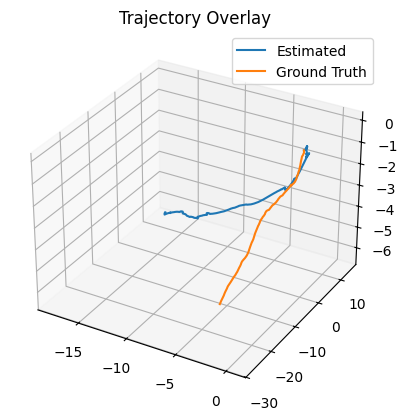

In [46]:
import matplotlib.pyplot as plt

def path_length(traj):
    """Compute the total Euclidean length of a trajectory (Nx3 array)."""
    return np.sum(np.linalg.norm(np.diff(traj, axis=0), axis=1))

# Make sure traj_est and traj_gt are both numpy arrays of shape (N, 3)
length_est = path_length(traj_est)
length_gt = path_length(traj_gt)
scale = length_gt / length_est
traj_est_scaled = traj_est * scale

offset = traj_gt[0] - traj_est_scaled[0]
traj_est_aligned = traj_est_scaled + offset

# Use traj_est_aligned and traj_gt for all downstream steps!
# Example visualization:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(traj_est_aligned[:,0], traj_est_aligned[:,1], traj_est_aligned[:,2], label='Estimated')
ax.plot(traj_gt[:,0], traj_gt[:,1], traj_gt[:,2], label='Ground Truth')
ax.legend()
plt.title("Trajectory Overlay")
plt.show()



## Qualitative Feature Tracking Demo

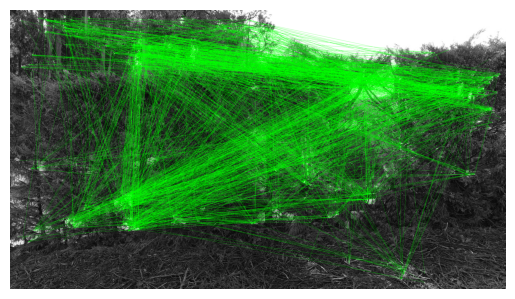

In [47]:
def draw_tracks(img, kp1, kp2, matches):
    out = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    for m in matches:
        pt1 = tuple(np.round(kp1[m.queryIdx].pt).astype(int))
        pt2 = tuple(np.round(kp2[m.trainIdx].pt).astype(int))
        cv2.line(out, pt1, pt2, (0,255,0), 1)
    plt.imshow(out); plt.axis("off")

# Example usage for frame i
draw_tracks(frames[i], kp_prev, kp, good)


## Discussion

Where drift appears most: Check plots where Euclidean/rotational error starts increasing quickly.

Explain whether drift is from poor feature tracking, scale ambiguity (monocular), or scene repetition.

Optimization for lightweight: Test with fewer features, lower image res, fast detector settings.

## Batch Flight Bundling


In [ ]:
video_files = [...] # list of all video paths
gt_files = [...]    # list of corresponding ground-truth logs

all_traj_est = []
all_traj_gt = []

for vid, gt in zip(video_files, gt_files):
    frames = ... # Extract frames
    trajectory = ... # Run SLAM or VO
    traj_gt = ... # Parse ground-truth
    all_traj_est.append(trajectory)
    all_traj_gt.append(traj_gt)

# Aggregate and analyze errors/metrics for all sequences
# Train/refine your model on the whole dataset
